In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [12]:
data = pd.read_stata('/workspaces/malnutrition/NPKR82FL.DTA')
data.head()

,caseid,bidx,v000,v001,v002,v003,v004,v005,v006,v007,...,s604c,s607ea,s607eb,s607ec,s607ed,s607ex,s607f,s607g,s615f,s631o
0,1 1 2,1,NP8,1,1,2,1,916093,magh,2078,...,no,no,no,no,no,no,no,no,NaN,NaN
1,1 8 2,1,NP8,1,8,2,1,916093,magh,2078,...,no,no,yes,no,no,no,NaN,no,NaN,no
2,1 8 2,2,NP8,1,8,2,1,916093,magh,2078,...,NaN,no,yes,no,no,no,NaN,no,NaN,no
3,1 9 3,1,NP8,1,9,3,1,916093,magh,2078,...,no,no,no,no,no,no,yes,no,NaN,no
4,1 19 1,1,NP8,1,19,1,1,916093,magh,2078,...,no,yes,yes,no,no,no,NaN,no,NaN,NaN


In [13]:
data.shape

(5372, 1422)

In [14]:
df1 = data.copy()
df1 = df1[['b19', 'v106', 'v525', 'v228', 'v190', 'v102', 'v101', 'v445', 'b11', 'v137', 'v208', 'v130', 'v131', 'm19', 'b4', 'm4', 'v012', 'v212', 'v729', 'v714', 'v481',  'hw71', 'hw70', 'hw72']]
df1.rename(columns={'b19': 'Child_age', 'v106':'Mother_education', 'v525': 'Age_first_sex', 'v228': 'Pregnancy_terminated', 'v190':'Wealth_index', 'v102':'Place_residence', 'v101':'Region', 'v445':'BMI', 'b11':'Birth_interval', 'v137':'Children_under5', 'v208': 'Total_children_ever_born', 'v130':'Religion', 'v131':'Ethnicity', 'm19':'Birth_weight', 'b4':'Child_sex', 'm4':'Breastfeeding_duration', 'v012':'Mother_age_current', 'v212': 'Mother_age_at_first_birth', 'v729':'Father_education', 'v714':'Mother_working', 'v481':'Health_insurance',  'hw71':'Underweight', 'hw70':'Stunting',  'hw72':'Wasting'}, inplace=True)
df1.head()

,Child_age,Mother_education,Age_first_sex,Pregnancy_terminated,Wealth_index,Place_residence,Region,BMI,Birth_interval,Children_under5,...,Child_sex,Breastfeeding_duration,Mother_age_current,Mother_age_at_first_birth,Father_education,Mother_working,Health_insurance,Underweight,Stunting,Wasting
0,41,basic,14.0,no,poorest,rural,koshi,NaN,36.0,1,...,female,NaN,29,17,complete primary,yes,no,NaN,NaN,NaN
1,28,basic,29.0,no,poorest,rural,koshi,NaN,13.0,2,...,female,still breastfeeding,33,30,incomplete primary,no,no,NaN,NaN,NaN
2,42,basic,29.0,no,poorest,rural,koshi,NaN,NaN,2,...,female,NaN,33,30,incomplete primary,no,no,NaN,NaN,NaN
3,17,basic,14.0,no,poorest,rural,koshi,2200.0,207.0,1,...,female,still breastfeeding,34,16,incomplete secondary,no,no,-65.0,-111.0,-19.0
4,40,secondary,17.0,yes,poorer,rural,koshi,2510.0,19.0,2,...,male,NaN,26,21,complete primary,yes,no,-185.0,-311.0,-7.0


In [15]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5372 entries, 0 to 5371
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Child_age                  5372 non-null   int8    
 1   Mother_education           5372 non-null   category
 2   Age_first_sex              5371 non-null   category
 3   Pregnancy_terminated       5372 non-null   category
 4   Wealth_index               5372 non-null   category
 5   Place_residence            5372 non-null   category
 6   Region                     5372 non-null   category
 7   BMI                        2736 non-null   category
 8   Birth_interval             3172 non-null   float64 
 9   Children_under5            5372 non-null   int8    
 10  Total_children_ever_born   5372 non-null   category
 11  Religion                   5372 non-null   category
 12  Ethnicity                  5372 non-null   category
 13  Birth_weight               3177 n

In [16]:
df1.isnull().sum()

Child_age                       0
Mother_education                0
Age_first_sex                   1
Pregnancy_terminated            0
Wealth_index                    0
Place_residence                 0
Region                          0
BMI                          2636
Birth_interval               2200
Children_under5                 0
Total_children_ever_born        0
Religion                        0
Ethnicity                       0
Birth_weight                 2195
Child_sex                       0
Breastfeeding_duration       2195
Mother_age_current              0
Mother_age_at_first_birth       0
Father_education               50
Mother_working                  0
Health_insurance                0
Underweight                  2771
Stunting                     2780
Wasting                      2780
dtype: int64

In [17]:
df2 = df1.copy()
df2.drop(index = 3251, inplace=True) # BMI 9998.0
df2.drop(index = [658,730, 4417], inplace = True) # Religion 96
df2.drop(index = [1369, 602, 603], inplace=True) # Ethnicity 96
df2 = df2[~df2['Birth_weight'].isin([9998, 9996])] # Birth_weight 9998 or 9996
df2 = df2[~df2['Wasting'].isin([9998, 9996])] # Wasting 9998 or 9996
df2.drop(index = 1651, inplace=True) # Status 9998

In [18]:
df2 = df2.dropna(subset=['Underweight', 'Stunting', 'Wasting'])

In [19]:
df2['BMI'] = df2['BMI']/100
df2['Underweight'] = df2['Underweight']/100
df2['Stunting'] = df2['Stunting']/100
df2['Wasting'] = df2['Wasting']/100
df2['Underweight'] = [0 if -2 <= val <= 2 else 1 for val in df2['Underweight']]
df2['Stunting'] = [0 if -2 <= val <= 2 else 1 for val in df2['Stunting']]
df2['Wasting'] = [0 if -2 <= val <= 2 else 1 for val in df2['Wasting']]

TypeError: unsupported operand type(s) for /: 'Categorical' and 'int'

In [ ]:
df3 = df2.drop(columns= ['Birth_weight', 'Birth_interval', 'Breastfeeding_duration'])
df3.head()

,Child_age,Mother_education,Age_first_sex,Pregnancy_terminated,Wealth_index,Place_residence,Region,BMI,Children_under5,Total_children_ever_born,...,Ethnicity,Child_sex,Mother_age_current,Mother_age_at_first_birth,Father_education,Mother_working,Health_insurance,Underweight,Stunting,Wasting
3,17,1,14.0,0,1,2,1,22.00,1,1,...,2,2,34,16,3.0,0,0,0,0,0
4,40,2,17.0,1,2,2,1,25.10,2,2,...,8,1,26,21,2.0,1,0,0,1,0
5,59,2,17.0,1,2,2,1,25.10,2,2,...,8,2,26,21,2.0,1,0,0,1,0
11,55,2,17.0,0,2,2,1,21.53,1,1,...,8,2,28,18,1.0,1,0,1,1,0
14,14,1,16.0,0,1,2,1,28.03,1,1,...,8,1,26,16,0.0,1,0,0,0,0


In [ ]:
df3 = df3.dropna(subset=['Age_first_sex', 'Father_education'])
df3.head()

,Child_age,Mother_education,Age_first_sex,Pregnancy_terminated,Wealth_index,Place_residence,Region,BMI,Children_under5,Total_children_ever_born,...,Ethnicity,Child_sex,Mother_age_current,Mother_age_at_first_birth,Father_education,Mother_working,Health_insurance,Underweight,Stunting,Wasting
3,17,1,14.0,0,1,2,1,22.00,1,1,...,2,2,34,16,3.0,0,0,0,0,0
4,40,2,17.0,1,2,2,1,25.10,2,2,...,8,1,26,21,2.0,1,0,0,1,0
5,59,2,17.0,1,2,2,1,25.10,2,2,...,8,2,26,21,2.0,1,0,0,1,0
11,55,2,17.0,0,2,2,1,21.53,1,1,...,8,2,28,18,1.0,1,0,1,1,0
14,14,1,16.0,0,1,2,1,28.03,1,1,...,8,1,26,16,0.0,1,0,0,0,0


In [ ]:
df3.shape

(2239, 21)

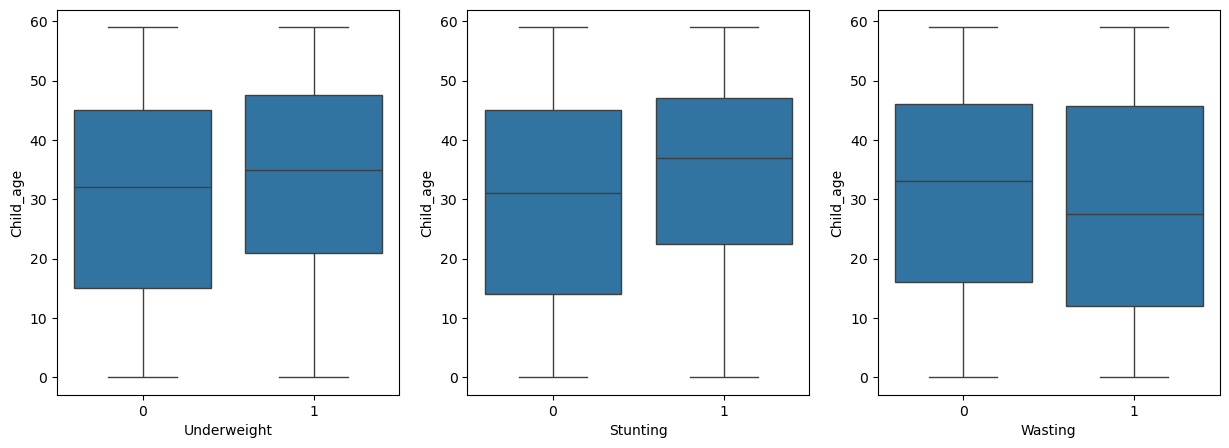

In [ ]:
fig, axis = plt.subplots(1, 3, figsize=(15,5))
sns.boxplot(x='Underweight', y='Child_age', data=df3, ax=axis[0])
sns.boxplot(x='Stunting', y='Child_age', data=df3, ax=axis[1])
sns.boxplot(x='Wasting', y='Child_age', data=df3, ax = axis[2])
plt.show()

In [ ]:
df3.head()

,Child_age,Mother_education,Age_first_sex,Pregnancy_terminated,Wealth_index,Place_residence,Region,BMI,Children_under5,Total_children_ever_born,...,Ethnicity,Child_sex,Mother_age_current,Mother_age_at_first_birth,Father_education,Mother_working,Health_insurance,Underweight,Stunting,Wasting
3,17,1,14.0,0,1,2,1,22.00,1,1,...,2,2,34,16,3.0,0,0,0,0,0
4,40,2,17.0,1,2,2,1,25.10,2,2,...,8,1,26,21,2.0,1,0,0,1,0
5,59,2,17.0,1,2,2,1,25.10,2,2,...,8,2,26,21,2.0,1,0,0,1,0
11,55,2,17.0,0,2,2,1,21.53,1,1,...,8,2,28,18,1.0,1,0,1,1,0
14,14,1,16.0,0,1,2,1,28.03,1,1,...,8,1,26,16,0.0,1,0,0,0,0


In [ ]:
df3_encoded = pd.get_dummies(df3, columns=['Region', 'Religion', 'Ethnicity'], drop_first=True)
df3_encoded = df3_encoded.astype({col: int for col in df3_encoded.select_dtypes('bool').columns})
df3_encoded.head()

,Child_age,Mother_education,Age_first_sex,Pregnancy_terminated,Wealth_index,Place_residence,BMI,Children_under5,Total_children_ever_born,Child_sex,...,Religion_5,Ethnicity_2,Ethnicity_3,Ethnicity_4,Ethnicity_5,Ethnicity_6,Ethnicity_7,Ethnicity_8,Ethnicity_9,Ethnicity_10
3,17,1,14.0,0,1,2,22.00,1,1,2,...,0,1,0,0,0,0,0,0,0,0
4,40,2,17.0,1,2,2,25.10,2,2,1,...,0,0,0,0,0,0,0,1,0,0
5,59,2,17.0,1,2,2,25.10,2,2,2,...,0,0,0,0,0,0,0,1,0,0
11,55,2,17.0,0,2,2,21.53,1,1,2,...,0,0,0,0,0,0,0,1,0,0
14,14,1,16.0,0,1,2,28.03,1,1,1,...,0,0,0,0,0,0,0,1,0,0


### Variance Inflation Factor Check

In [ ]:
# df3_vif = df3.drop(columns=['Underweight', 'Stunting', 'Wasting'])

X = add_constant(df3_encoded)

# Calculate VIF for each variable
vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

print(vif)

                     Variable         VIF
0                       const  149.126784
1                   Child_age    1.229896
2            Mother_education    1.938338
3        Pregnancy_terminated    1.048920
4                Wealth_index    1.997186
5             Place_residence    1.169873
6                         BMI    1.281291
7             Children_under5    1.661102
8    Total_children_ever_born    1.703218
9                   Child_sex    1.025716
10         Mother_age_current    1.952648
11  Mother_age_at_first_birth    1.872679
12           Father_education    1.382112
13             Mother_working    1.191349
14           Health_insurance    1.149408
15                Underweight    1.581321
16                   Stunting    1.372071
17                    Wasting    1.240816
18                   Region_2    2.673724
19                   Region_3    1.868359
20                   Region_4    1.635588
21                   Region_5    1.824630
22                   Region_6    2

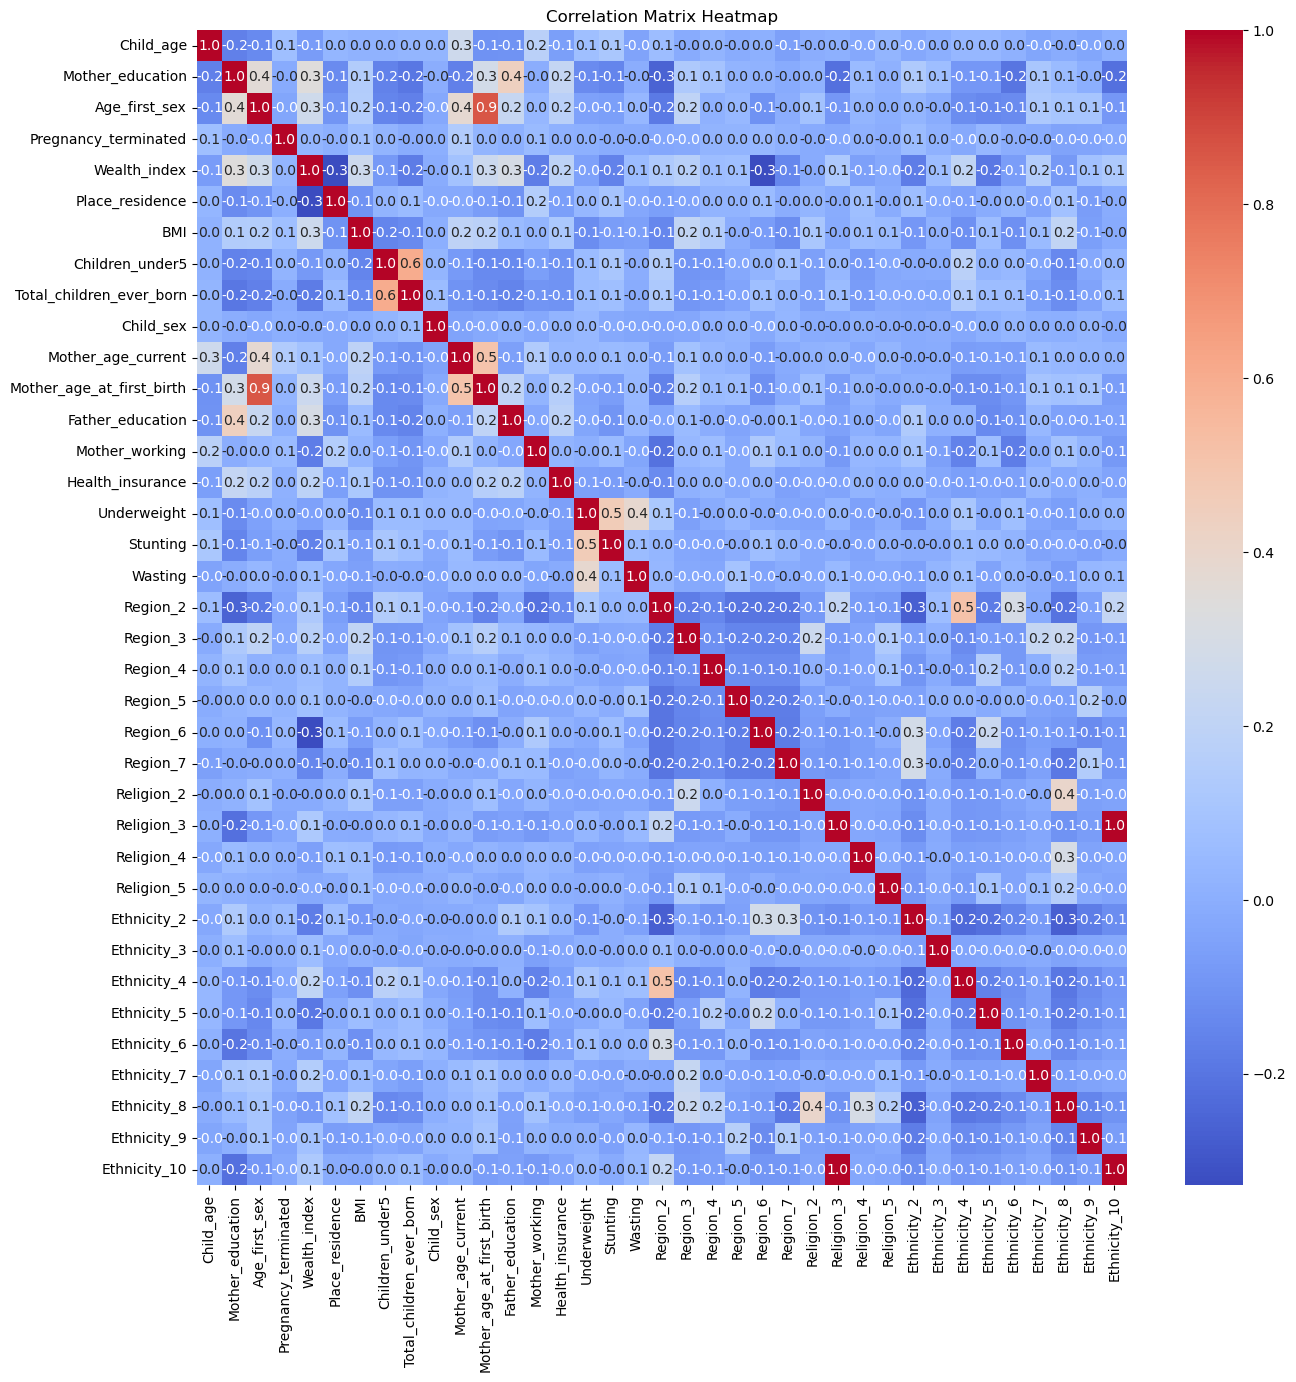

In [ ]:
# Create a heatmap
correlation_matrix = df3_encoded.corr()

plt.figure(figsize=(15, 15))  # Set figure size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.1f')
plt.title("Correlation Matrix Heatmap")
plt.show()


In [ ]:
df3_encoded = df3_encoded.drop(columns=['Ethnicity_10', 'Age_first_sex'])

In [ ]:
# Add constant
X = add_constant(df3_encoded)

# Calculate VIF
vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

print(vif)

                     Variable         VIF
0                       const  149.126784
1                   Child_age    1.229896
2            Mother_education    1.938338
3        Pregnancy_terminated    1.048920
4                Wealth_index    1.997186
5             Place_residence    1.169873
6                         BMI    1.281291
7             Children_under5    1.661102
8    Total_children_ever_born    1.703218
9                   Child_sex    1.025716
10         Mother_age_current    1.952648
11  Mother_age_at_first_birth    1.872679
12           Father_education    1.382112
13             Mother_working    1.191349
14           Health_insurance    1.149408
15                Underweight    1.581321
16                   Stunting    1.372071
17                    Wasting    1.240816
18                   Region_2    2.673724
19                   Region_3    1.868359
20                   Region_4    1.635588
21                   Region_5    1.824630
22                   Region_6    2

In [ ]:
df3_encoded.to_csv("C:/Users/dbastola2022/OneDrive - Florida Atlantic University/Academics/Research/NDHS/Dataset/Children's Recode/Children Recode_final.csv", index=False)